In [95]:
# Bài toán: Dự đoán Khả năng Nợ xấu (Credit Scoring)
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [96]:
df_training = pd.read_csv('F:/MachineLearning Tutorial/datasets/GiveMeSomeCredit/cs-training.csv')

In [97]:
# Data Preprocessing
# df['MonthlyIncome'] 
# Xu li du lieu thieu va missing valueses
print(df_training['MonthlyIncome'].isnull().sum())
median_income = df_training['MonthlyIncome'].median()
df_training['MonthlyIncome'] = df_training['MonthlyIncome'].fillna(median_income)

29731


In [98]:
# Kiểm tra dữ liệu có bất thường không va Xu li gia tri ngoai le
print(df_training[(df_training['age'] < 18) | (df_training['age'] > 100)])
# Loai bỏ các giá trị ngoại lệ
df_training = df_training[(df_training['age']>18) & (df_training['age']<100)]

        Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
7763          7764                 0                              0.069167   
19884        19885                 0                              1.000000   
25561        25562                 0                              0.009866   
40007        40008                 0                              0.064748   
56761        56762                 0                              0.003469   
57967        57968                 0                              0.001397   
65695        65696                 0                              1.000000   
90937        90938                 0                              0.000000   
93813        93814                 0                              0.025780   
96450        96451                 0                              0.109642   
105790      105791                 0                              0.109307   
116129      116130                 1                            

In [99]:
df_training = pd.get_dummies(df_training, drop_first=True)

In [100]:
X = df_training.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'])
y = df_training['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [101]:

X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [102]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [103]:
model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [104]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [105]:
# Danh gia mo hinh
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7573838255883726
Precision: 0.17072561508679904
Recall: 0.6817955112219451
F1 Score: 0.27307231322413106
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.76      0.85     27993
           1       0.17      0.68      0.27      2005

    accuracy                           0.76     29998
   macro avg       0.57      0.72      0.56     29998
weighted avg       0.92      0.76      0.82     29998



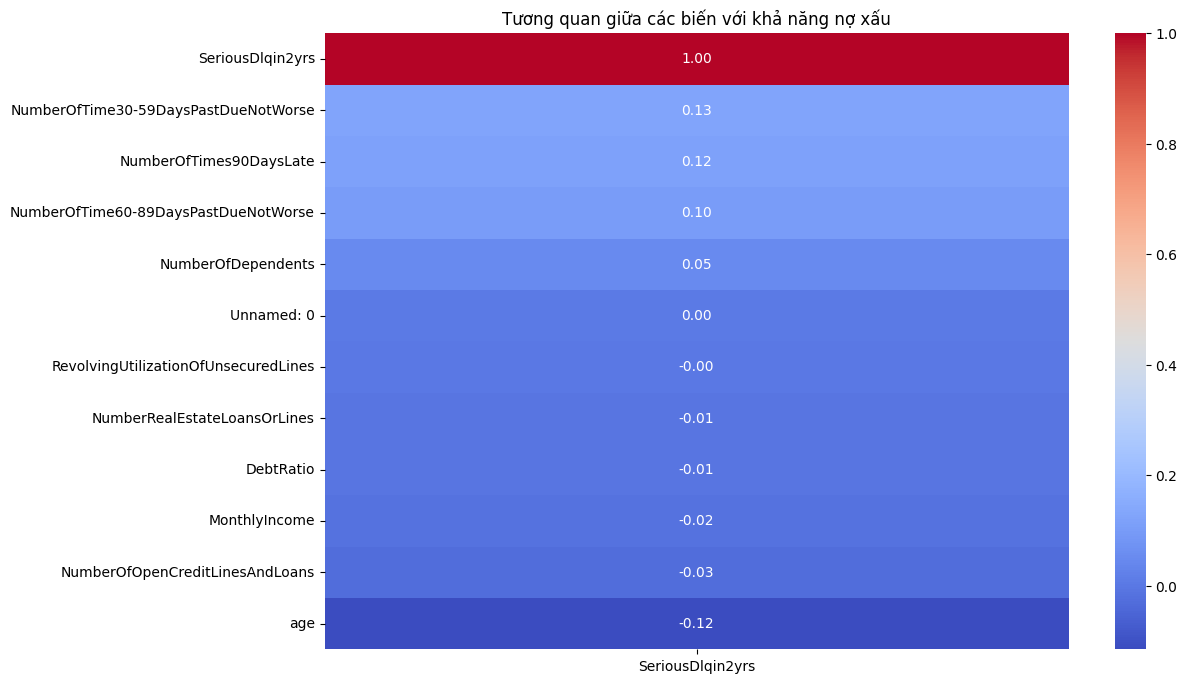

In [112]:
plt.figure(figsize=(12, 8))
# Chỉ lấy các cột số và tính tương quan với SeriousDlqin2yrs
corr = df_training.corr()
sns.heatmap(corr[['SeriousDlqin2yrs']].sort_values(by='SeriousDlqin2yrs', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Tương quan giữa các biến với khả năng nợ xấu")
plt.show()

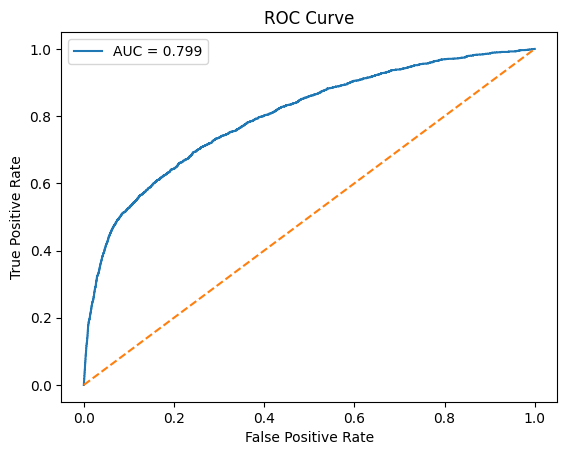

In [107]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [108]:
# Trọng số của model
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                                Feature  Coefficient
2  NumberOfTime30-59DaysPastDueNotWorse     2.162823
6               NumberOfTimes90DaysLate     1.991219
7          NumberRealEstateLoansOrLines     0.076797
9                    NumberOfDependents     0.071777
0  RevolvingUtilizationOfUnsecuredLines    -0.002069
5       NumberOfOpenCreditLinesAndLoans    -0.004739
8  NumberOfTime60-89DaysPastDueNotWorse    -0.007363
3                             DebtRatio    -0.089319
4                         MonthlyIncome    -0.234187
1                                   age    -0.446767


In [109]:
import joblib

joblib.dump(model, "F:/MachineLearning Tutorial/notebooks/model save/logistic_model.pkl")
joblib.dump(scaler, "F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl")

['F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl']

In [110]:
model = joblib.load("F:/MachineLearning Tutorial/notebooks/model save/logistic_model.pkl")
scaler = joblib.load("F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl")

<Axes: >

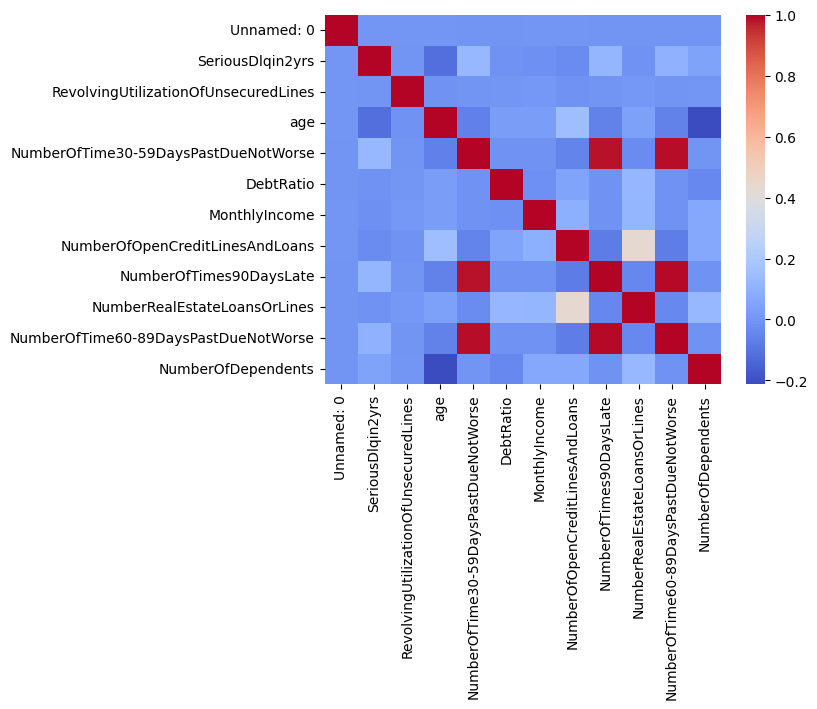

In [111]:
sns.heatmap(df_training.corr(), cmap='coolwarm')